# STalign parity: `merfish-visium-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-visium-alignment.ipynb).

Status: `compared`. Both passes skipped 6 cell(s) unrelated to the fit -- cell 30: RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!; cell 31: NameError: name 'muA' is not defined; cell 35: RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!; cell 36: NameError: name 'muA' is not defined; cell 37: RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!; cell 38: NameError: name 'muA' is not defined


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 1.307072233385697e-06,
  "AI relative L2": 0.0,
  "L relative L2": 0.0,
  "V relative L2": 0.0,
  "Vnorm relative L2": 0.0,
  "WA relative L2": 0.0,
  "WB relative L2": 0.0,
  "WM relative L2": 0.0,
  "df3 relative L2": 1.4112568577295036e-05,
  "extentI relative L2": 0.0,
  "extentJ relative L2": 0.0,
  "levels relative L2": 0.0,
  "phiI relative L2": 0.00029308889400563715,
  "phii relative L2": 1.6738467739480257e-05,
  "phiipointsI relative L2": 1.7949422164379315e-05,
  "pointsI relative L2": 0.0,
  "pointsJ relative L2": 0.0,
  "squidpy vs upstream published relative L2": 1.3593624470364794e-05,
  "tpointsI relative L2": 1.4112568577295038e-05,
  "trans_offset_0 relative L2": 0.0,
  "trans_offset_1 relative L2": 0.0,
  "upstream vs upstream published relative L2": 1.1140520220234532e-06,
  "v relative L2": 2.6788368921300466e-05,
  "xI_LDDMM relative L2": 1.3312749904653129e-05,
  "yI_LDDMM relative L2": 1.4390448940230954e-05
}

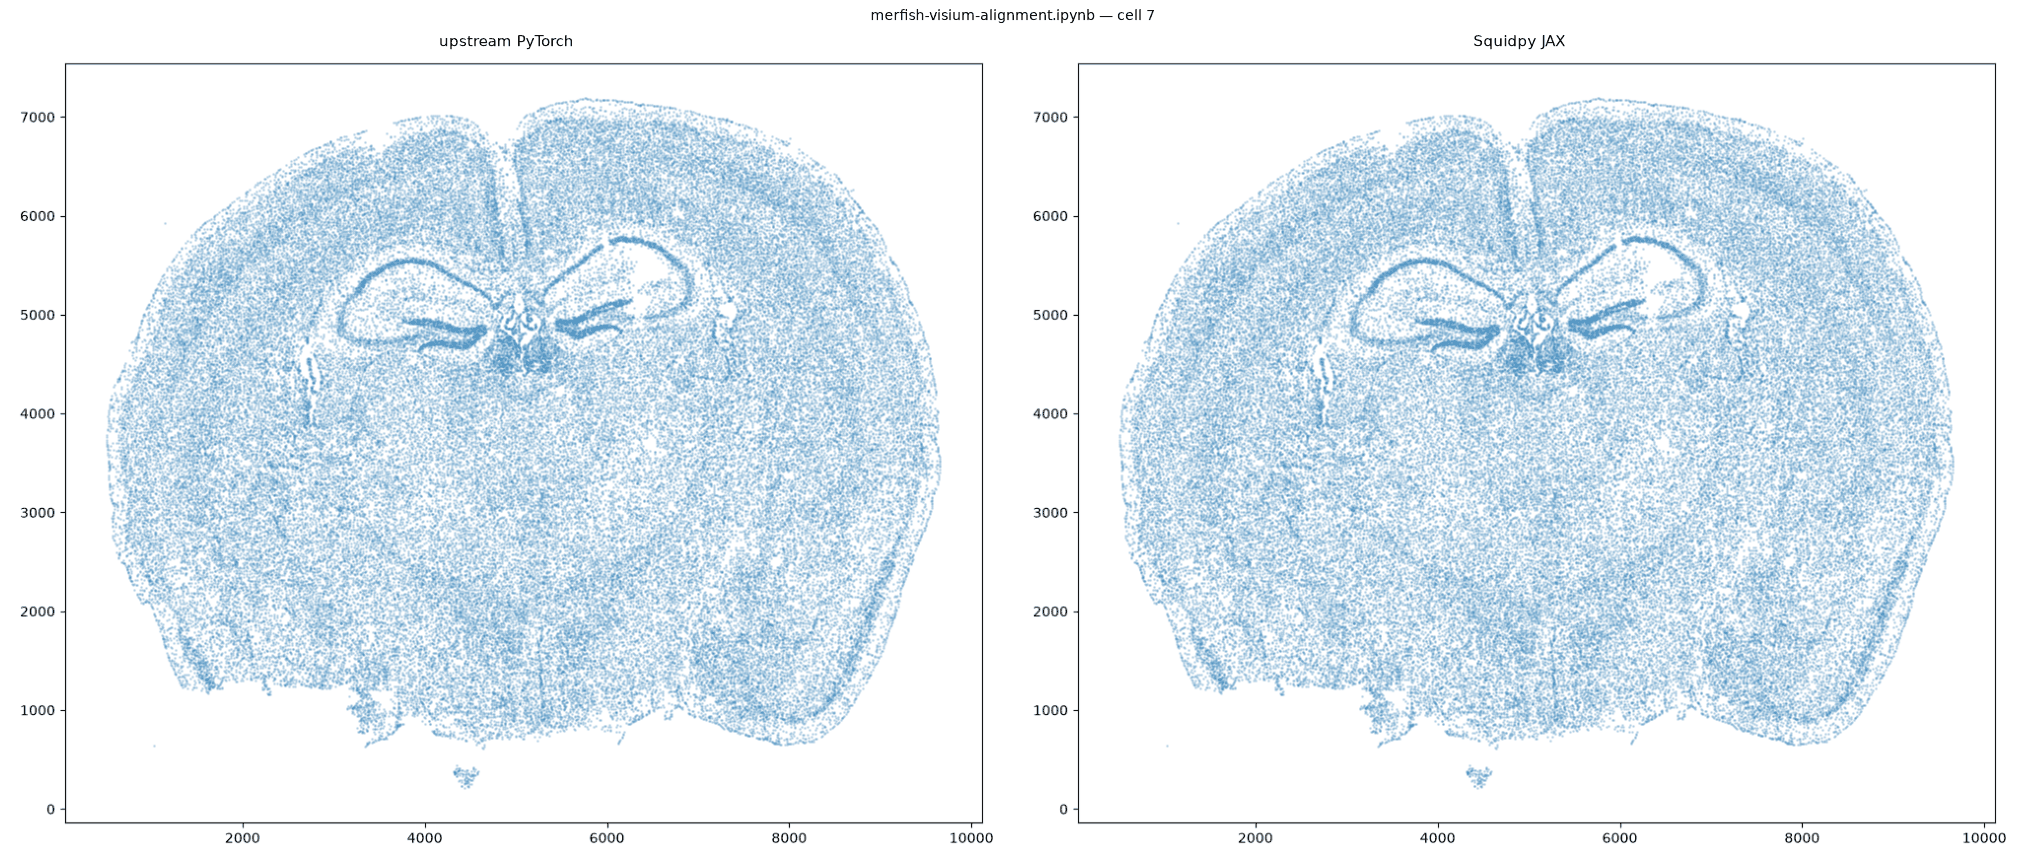

In [2]:
# get cell centroid coordinates
xI = np.array(df1['center_x'])
yI = np.array(df1['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)
#ax.set_aspect('equal', 'box')

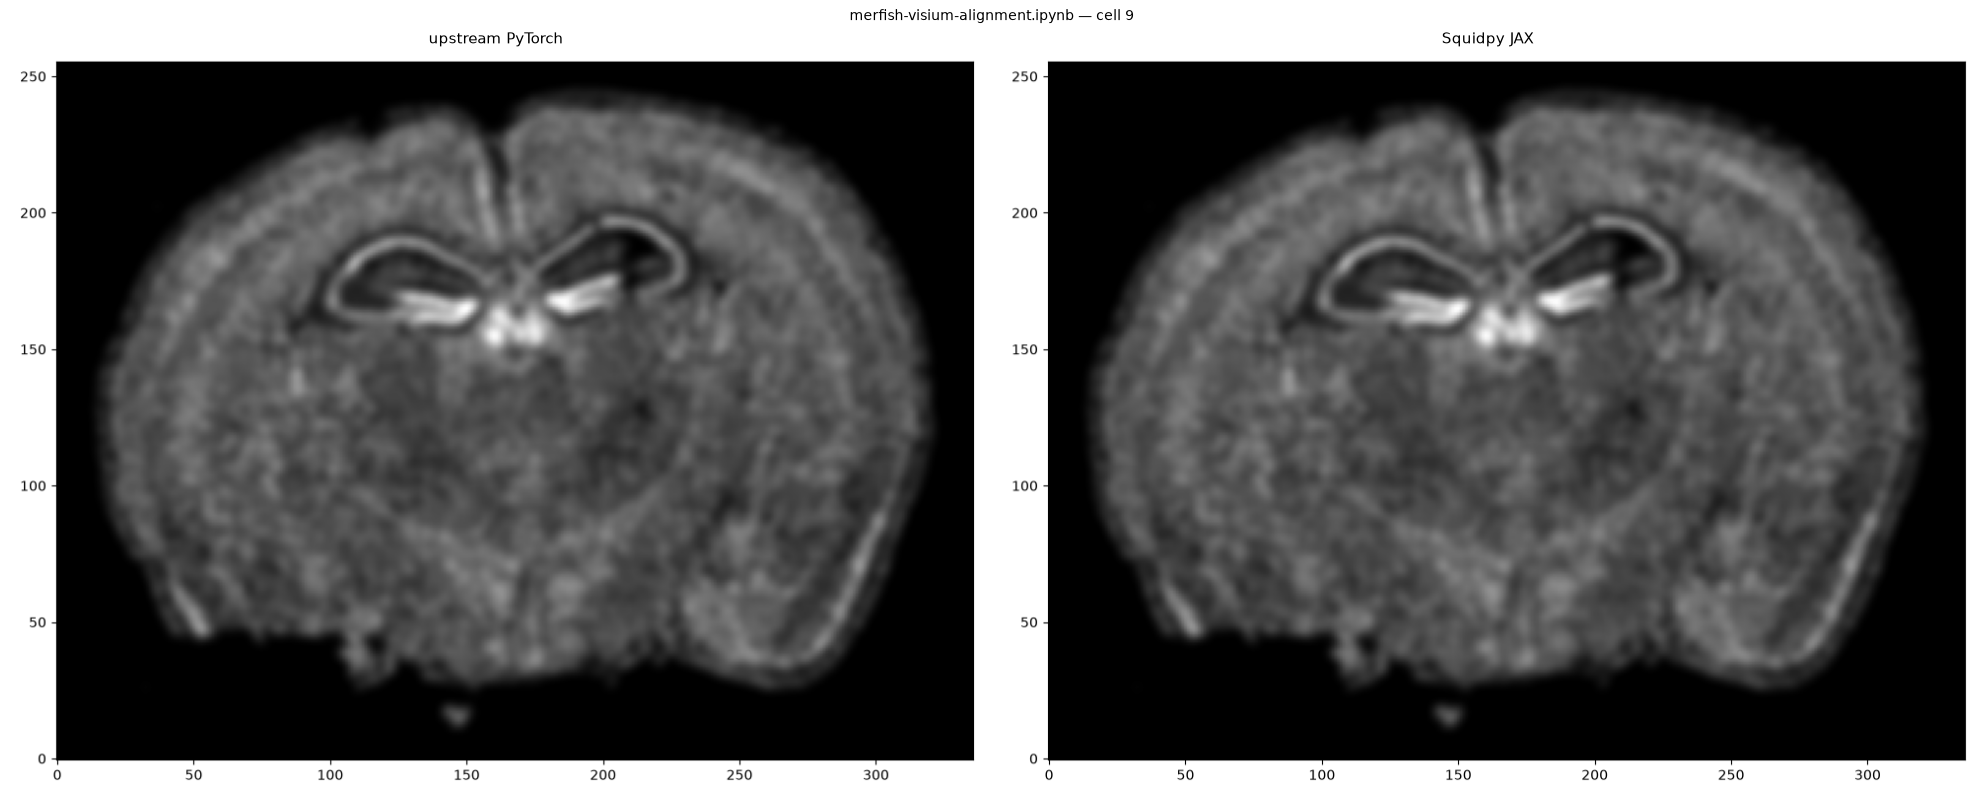

In [3]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI, yI, dx=30)

ax = fig.axes[0]
ax.invert_yaxis()

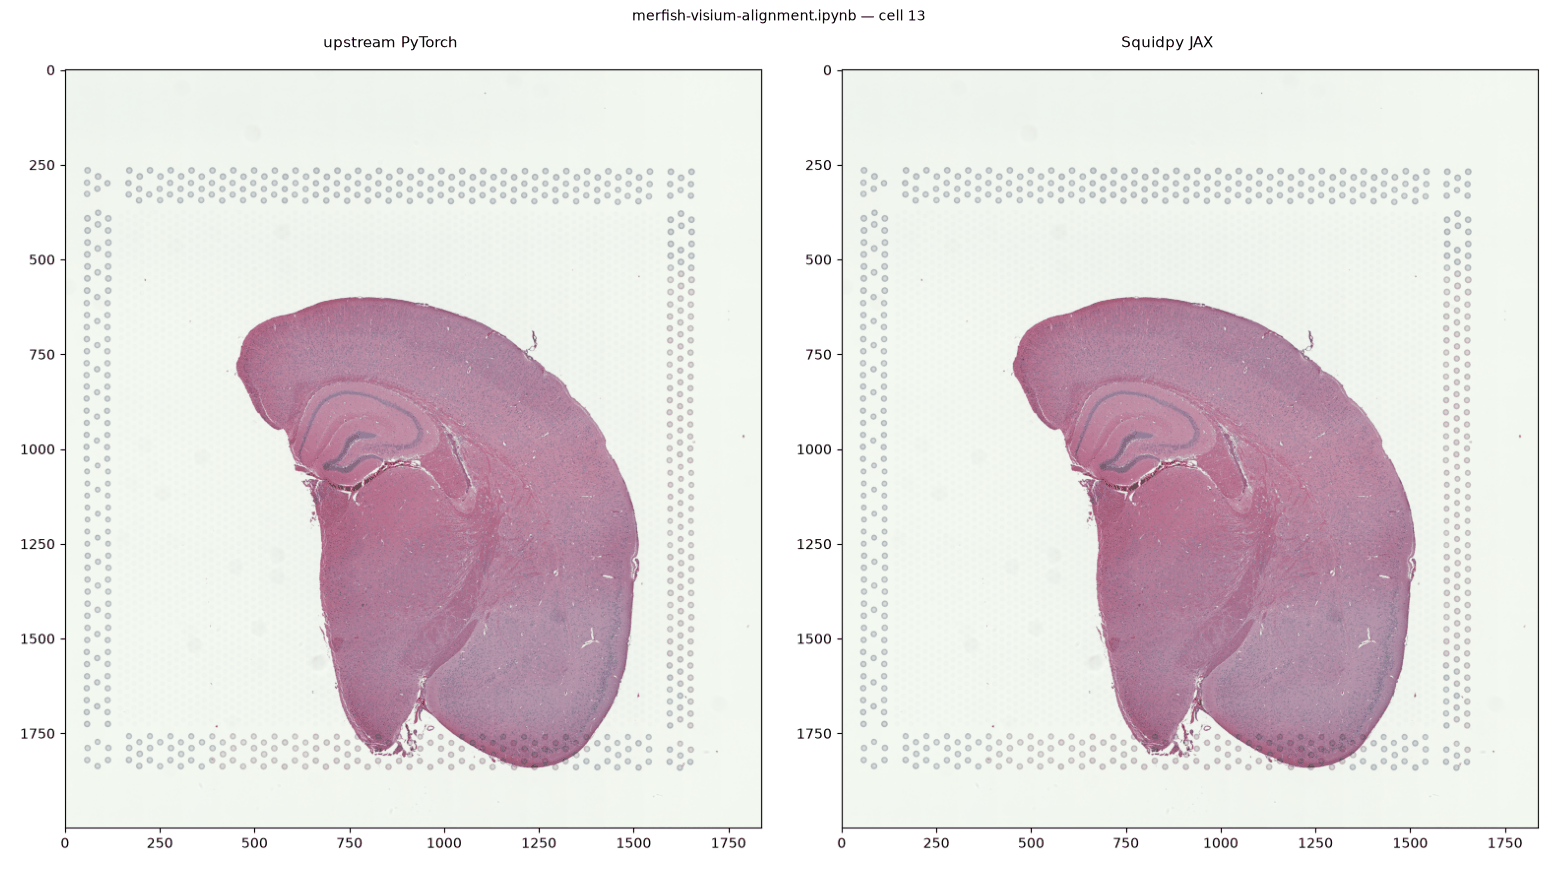

In [4]:
image_file = '../visium_data/tissue_hires_image.png'
V = plt.imread(image_file)

# plot
fig,ax = plt.subplots()
ax.imshow(V)

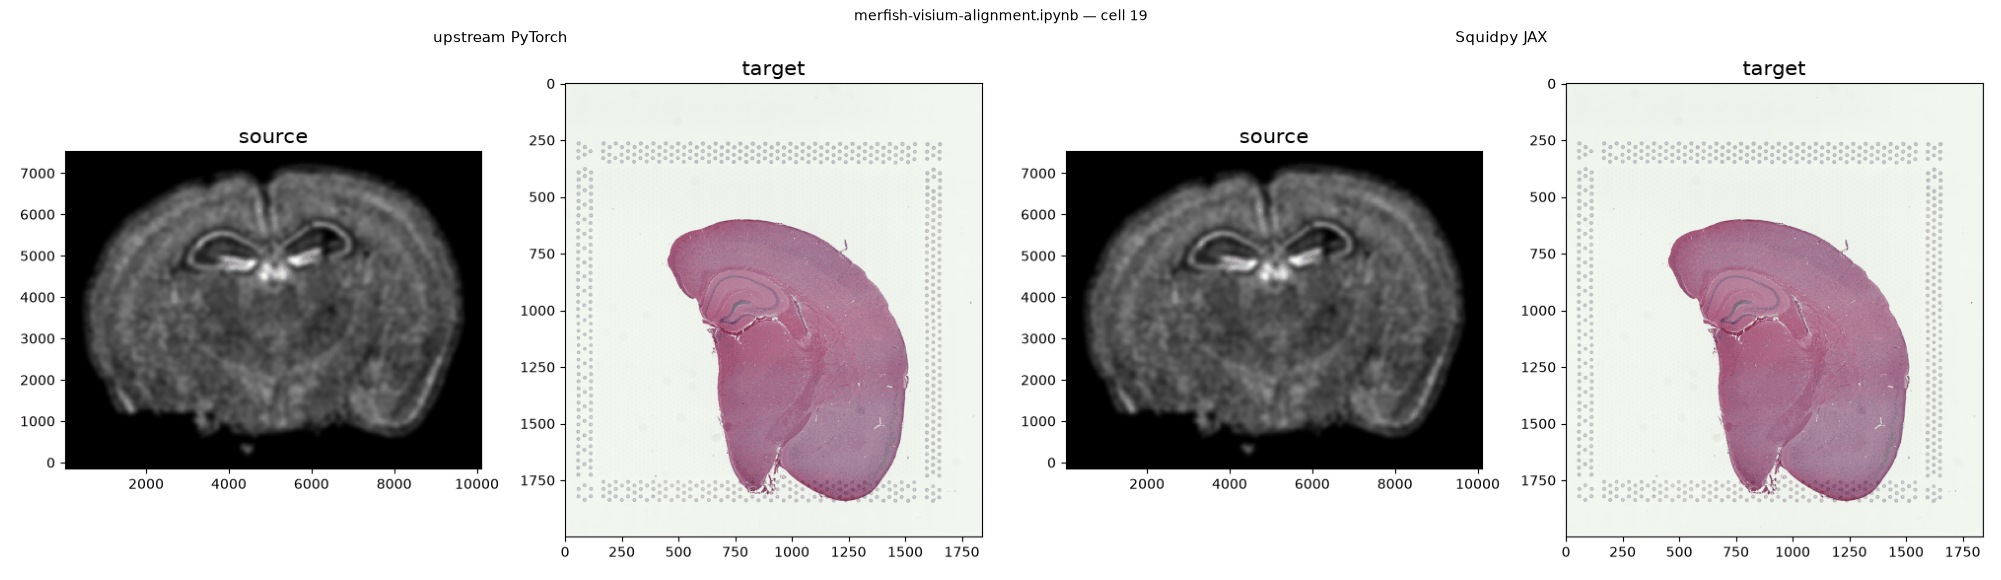

In [5]:
# plot
extentI = STalign.extent_from_x((YI,XI))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[0].invert_yaxis()
ax[0].set_title('source', fontsize=15)
ax[1].imshow((J).transpose(1,2,0))
ax[1].set_title('target', fontsize=15)

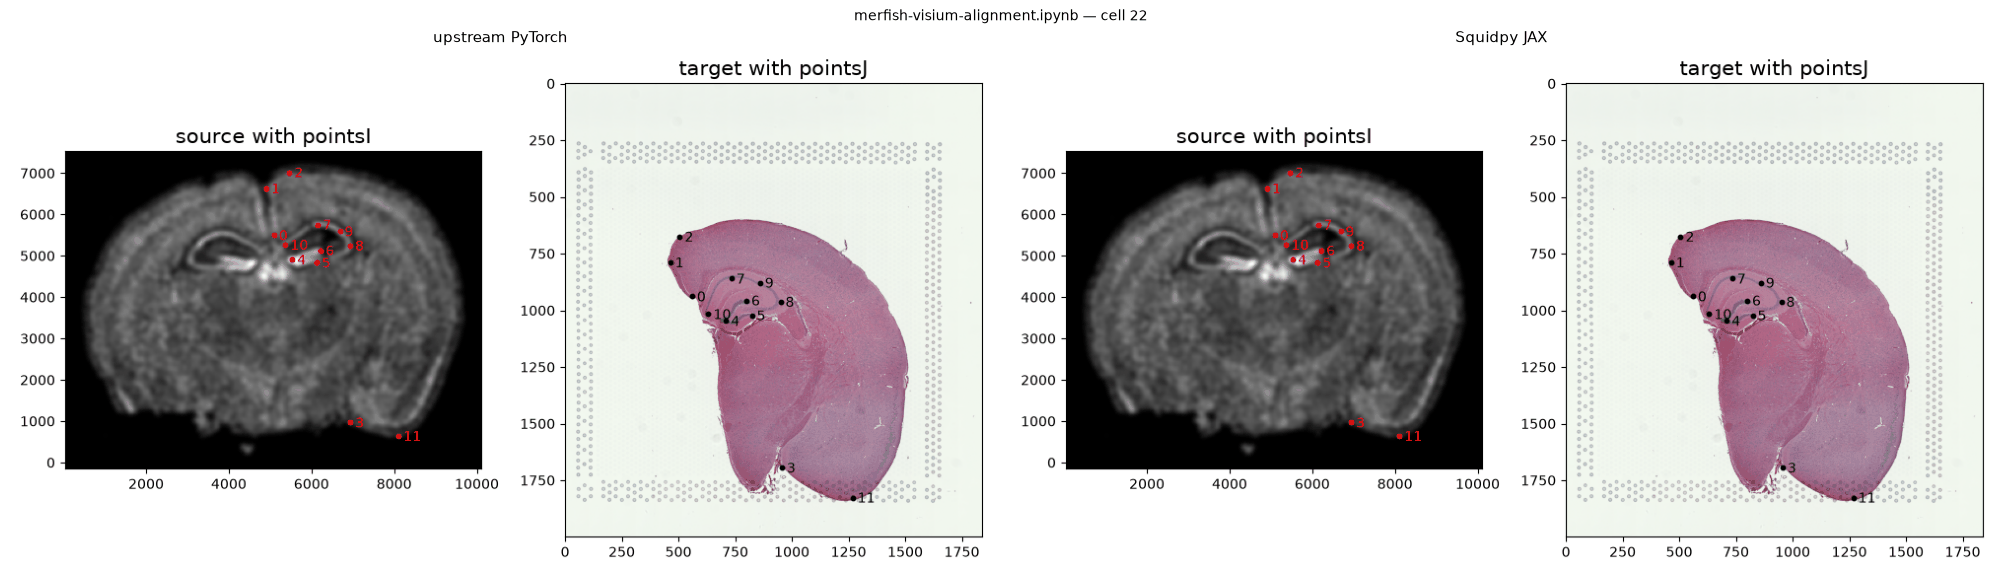

In [6]:
# plot
extentJ = STalign.extent_from_x((YJ,XJ))
extentI = STalign.extent_from_x((YI,XI))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

trans_offset_0 = mtransforms.offset_copy(ax[0].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')
trans_offset_1 = mtransforms.offset_copy(ax[1].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red', s=10)
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='black', s=10)
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red', transform=trans_offset_0)
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='black', transform=trans_offset_1)

ax[0].set_title('source with pointsI', fontsize=15)
ax[1].set_title('target with pointsJ', fontsize=15)

# invert only rasterized image
ax[0].invert_yaxis()

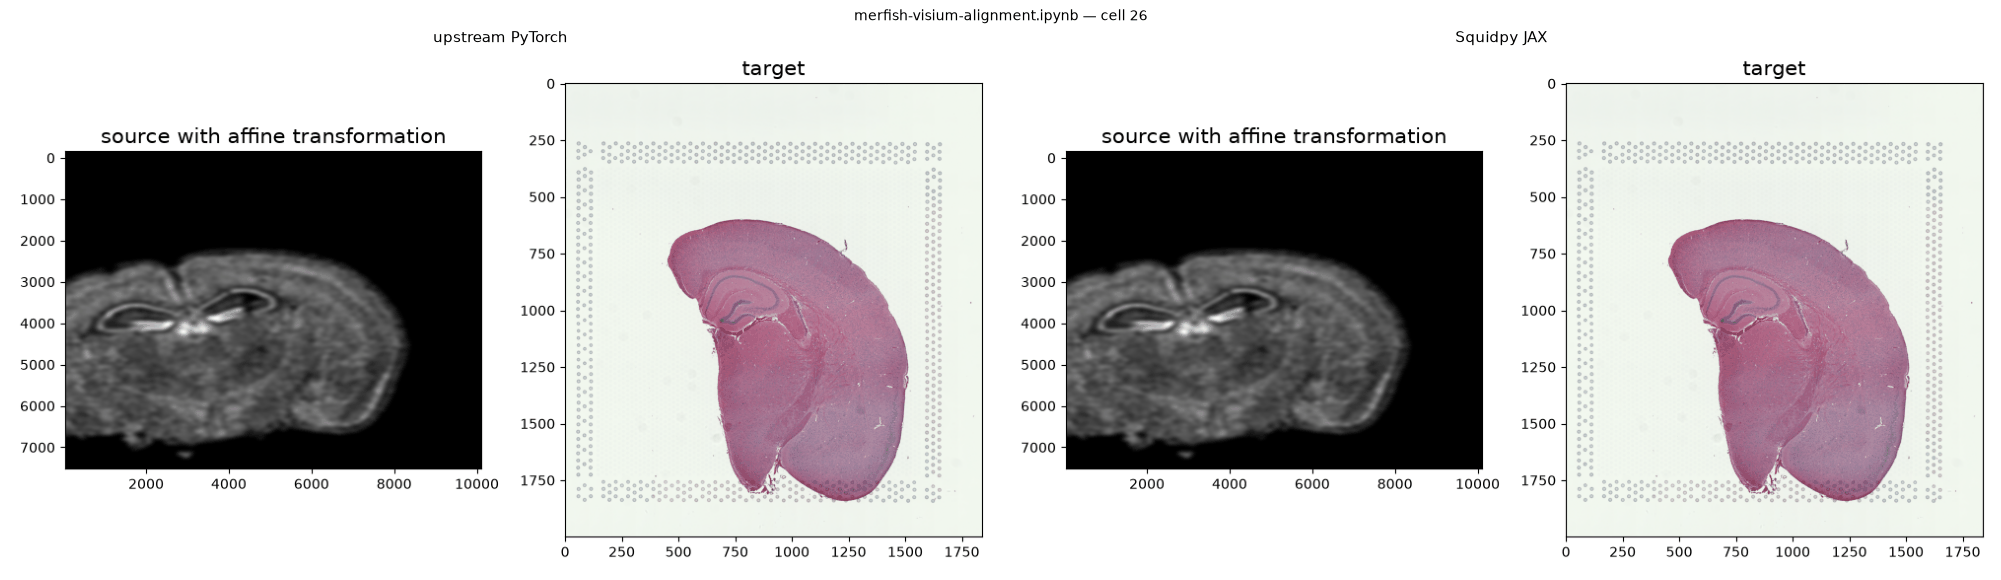

In [7]:
# compute initial affine transformation from points
AI= STalign.transform_image_source_with_A(A, [YI,XI], I, [YJ,XJ])

# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

fig,ax = plt.subplots(1,2)
#ax[0].imshow(AI[0], extent=extentI)
ax[0].imshow((AI.permute(1,2,0).squeeze()), extent=extentI) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 

ax[0].set_title('source with affine transformation', fontsize=15)
ax[1].set_title('target', fontsize=15)

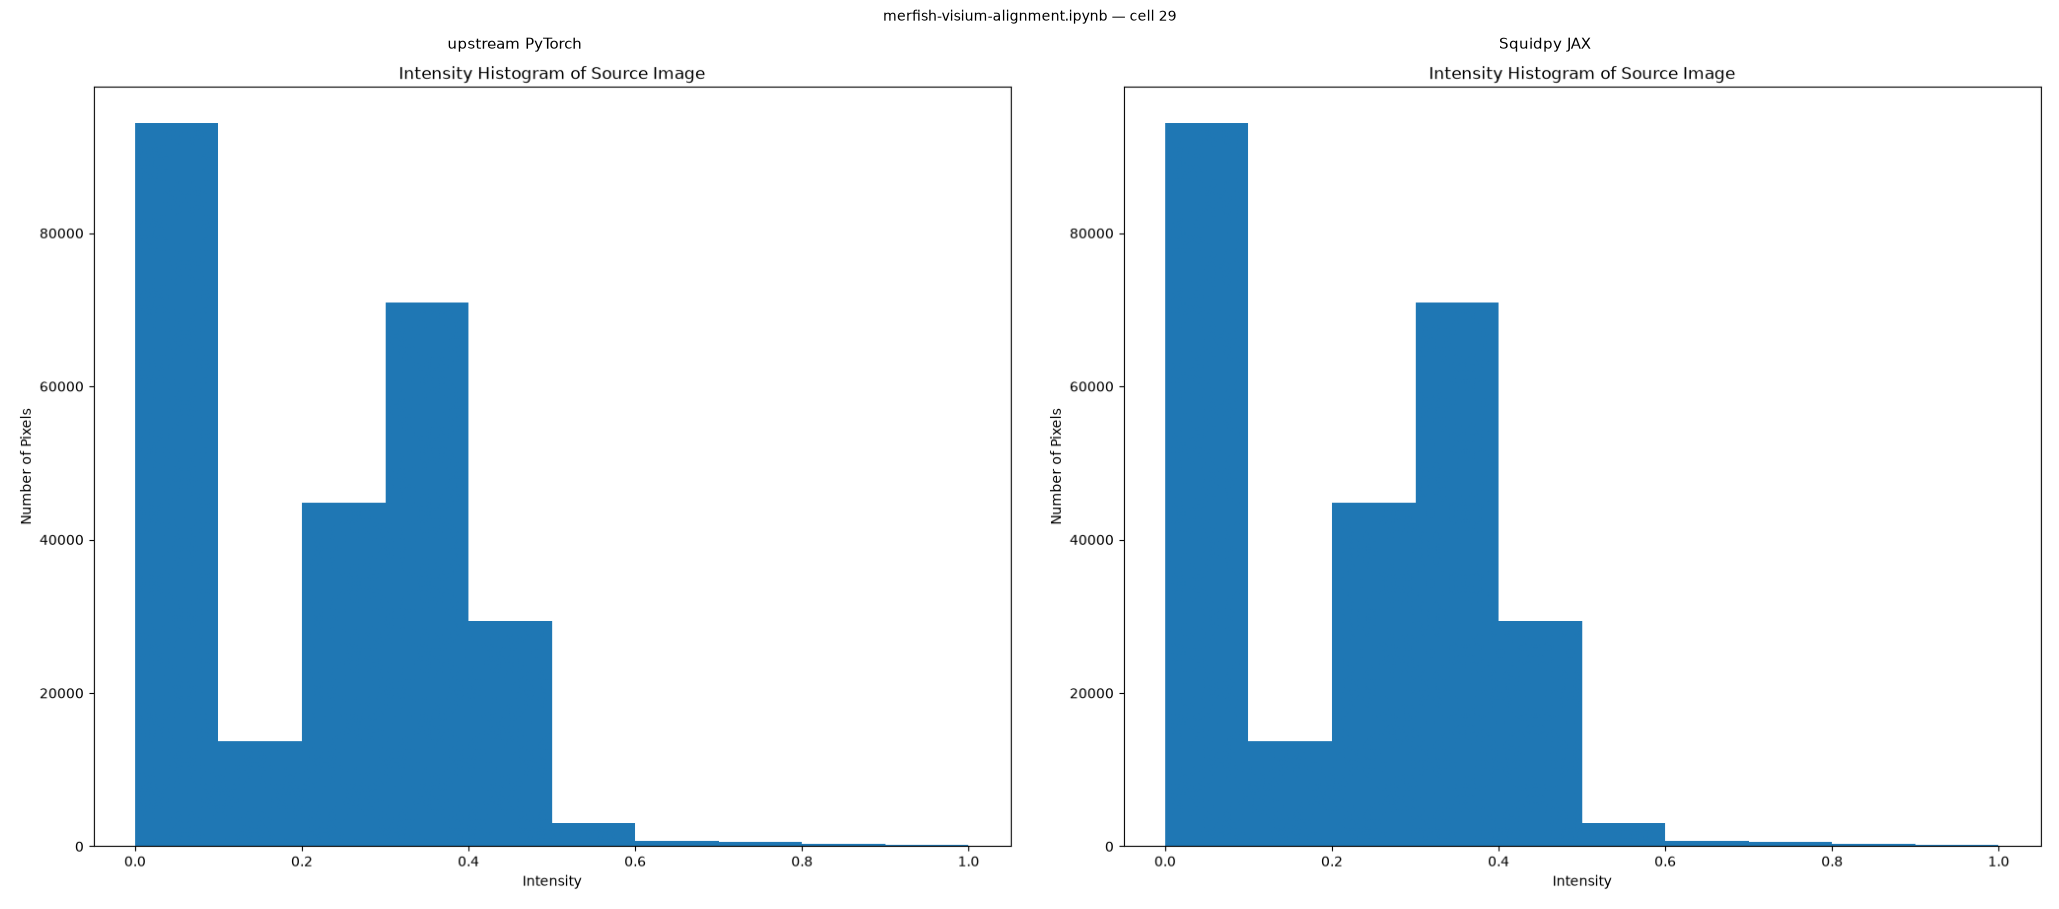

In [8]:
fig,ax = plt.subplots()
ax.hist(I.ravel())
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.title('Intensity Histogram of Source Image')

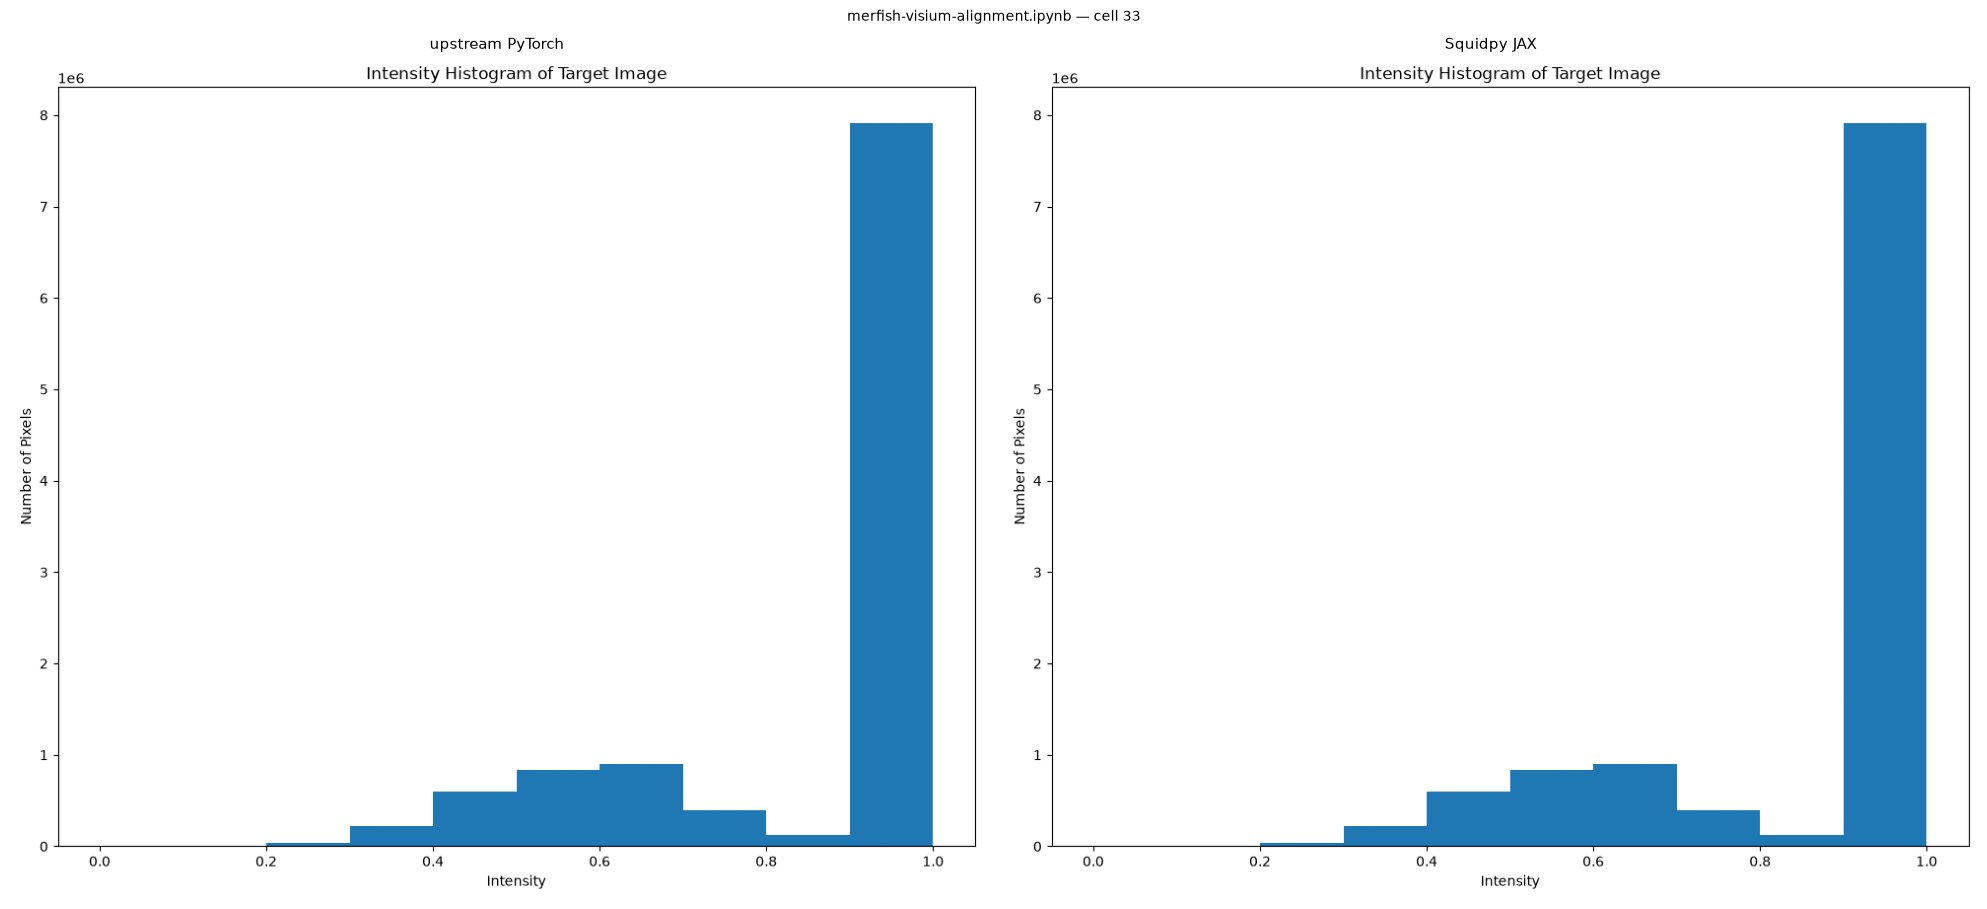

In [9]:
fig,ax = plt.subplots()
ax.hist(J.ravel())
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.title('Intensity Histogram of Target Image')

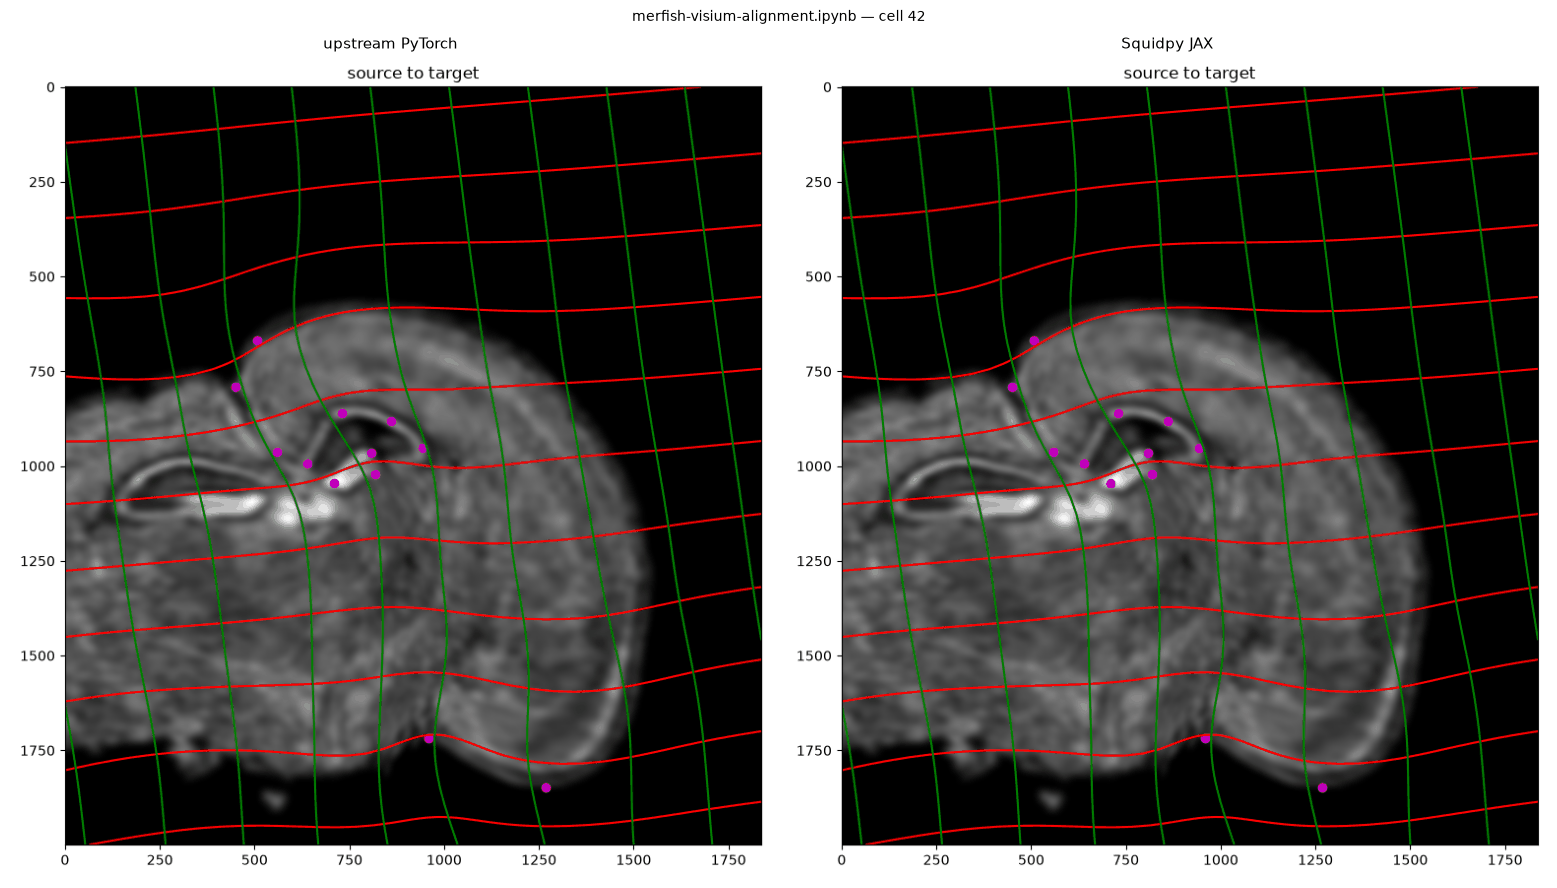

In [10]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])
phiipointsI = STalign.transform_points_source_to_target(xv,v,A,pointsI)

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('source to target')
ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
ax.scatter(phiipointsI[:,1].detach(),phiipointsI[:,0].detach(),c="m")

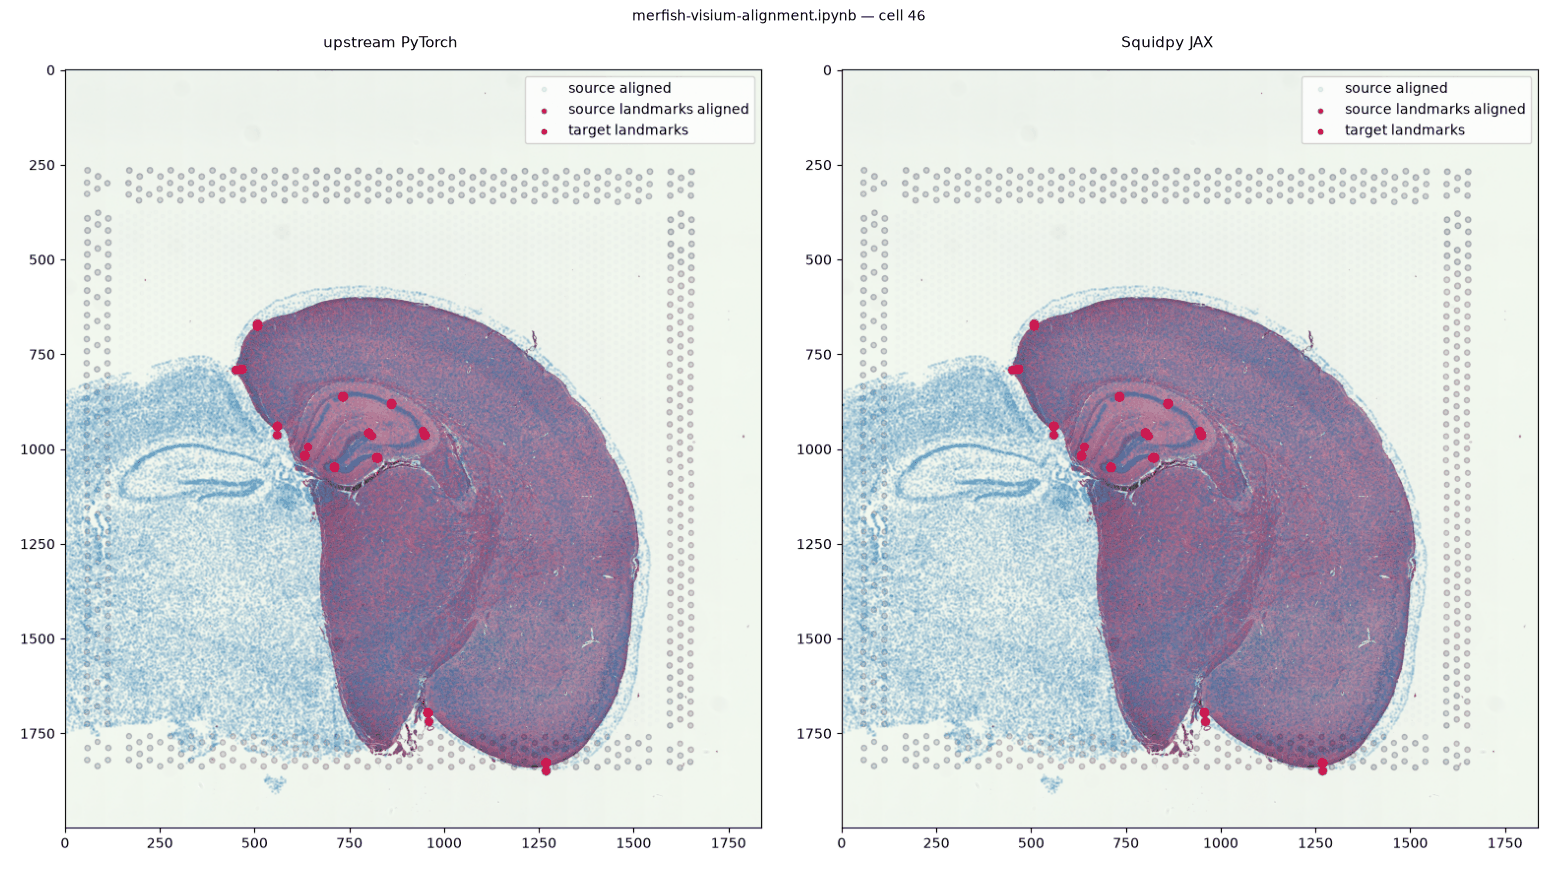

In [11]:
# plot
#fig,ax = plt.subplots()
#ax.imshow((I).transpose(1,2,0),extent=extentI)
#ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="r")
#ax.scatter(tpointsI[:,1].detach(),tpointsI[:,0].detach(),s=1,alpha=0.1)

# plot results
fig,ax = plt.subplots()
#ax.scatter(xI,yI,s=1,alpha=0.1, label='source')
ax.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.1, label = 'source aligned')
ax.scatter(phiipointsI[:,1].detach(),phiipointsI[:,0].detach(),c="m", label='source landmarks aligned')
ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', label='target landmarks')
ax.imshow((J).transpose(1,2,0),extent=extentJ)

lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])